# Experiment 4
## Text Preprocessing and Word Frequency Analysis

**Name:** Ayush Gupta  
**SAP ID:** 500125537  
**Batch:** B7  
**Course:** Natural Language Processing Lab

### Aim
To read a text document as input and preprocess the text by

a. converting the text to lower case  
b. removing the punctuation marks  
c. removing the stop words  
d. tokenizing the text into words

and then to answer the following

**Q1.** Calculate the total number of words in the document.  
**Q2.** Find the top 10 most frequent words and display their frequencies.  
**Q3.** Plot a bar graph showing the top 10 frequent words.

### Theory
Raw text cannot be given directly to any NLP model, it has to be cleaned first. This cleaning is called **preprocessing** and these are the usual steps.

**Lower case conversion** is done so that the same word written in different cases is counted as one word. Without this, "Language", "language" and "LANGUAGE" become three different words in the frequency count.

**Punctuation removal** takes out the symbols like . , ! ? which do not carry any meaning of their own. If they are not removed then the tokenizer returns them as seperate tokens and they come in the frequency list.

**Tokenization** breaks the text into words, and each word is called a token.

**Stop words** are the very common words of a language such as the, is, of, and, a. They are needed for the grammar but they do not tell anything about the topic of the document, and they are the most frequent words in almost every English text. If they are not removed then the top of the frequency list is filled with these words only and the actual subject of the document stays hidden. NLTK gives a ready list of English stop words.

**Word frequency analysis** means counting how many times each word appears. After the stop words are removed the most frequent words usually describe the topic of the document, which is why this simple method is used for keyword extraction and for word clouds.

### 1. Reading the text document
The document `document.txt` is an article about natural language processing and its applications.

In [1]:
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

file = open("document.txt", "r", encoding="utf-8")
raw_text = file.read()
file.close()

print("total characters in the document :", len(raw_text))
print("total lines :", len(raw_text.split("\n")))
print()
print(raw_text[:400], "...")

total characters in the document : 3071
total lines : 14

Natural Language Processing and its Applications

Natural language processing is a branch of artificial intelligence which deals with the interaction between computers and human language. The main goal of natural language processing is to allow a computer to read, understand and generate human language in a useful way. Human language is not simple for a machine because the same sentence can have m ...


### 2. (a) Converting the text to lower case

In [2]:
lower_text = raw_text.lower()

print(lower_text[:250])

natural language processing and its applications

natural language processing is a branch of artificial intelligence which deals with the interaction between computers and human language. the main goal of natural language processing is to allow a com


### 3. (b) Removing the punctuation marks
`string.punctuation` has all the punctuation symbols, and `str.maketrans` is used to delete all of them in one go.

In [3]:
print("punctuation symbols :", string.punctuation)

table = str.maketrans("", "", string.punctuation)
no_punct_text = lower_text.translate(table)

print()
print("before :", lower_text[:150])
print()
print("after  :", no_punct_text[:150])

punctuation symbols : !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~

before : natural language processing and its applications

natural language processing is a branch of artificial intelligence which deals with the interaction 

after  : natural language processing and its applications

natural language processing is a branch of artificial intelligence which deals with the interaction 


### 4. (d) Tokenizing the text into words
Tokenization is done before removing the stop words, because the stop words have to be removed word by word and for that the text must already be in the form of a list of words.

In [4]:
tokens = word_tokenize(no_punct_text)

print("total tokens :", len(tokens))
print()
print("first 30 tokens :")
print(tokens[:30])

total tokens : 500

first 30 tokens :
['natural', 'language', 'processing', 'and', 'its', 'applications', 'natural', 'language', 'processing', 'is', 'a', 'branch', 'of', 'artificial', 'intelligence', 'which', 'deals', 'with', 'the', 'interaction', 'between', 'computers', 'and', 'human', 'language', 'the', 'main', 'goal', 'of', 'natural']


### 5. (c) Removing the stop words
The English stop word list of NLTK is used. Along with the stop words, anything which is not a proper word (a number for example) is also dropped using `isalpha()`.

In [5]:
stop_words = set(stopwords.words("english"))

print("number of stop words in the nltk list :", len(stop_words))
print("some of them :", sorted(list(stop_words))[:15])

number of stop words in the nltk list : 198
some of them : ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't"]


In [16]:
filtered_words = []

for w in tokens:
    if w not in stop_words and w.isalpha():
        filtered_words.append(w)

print("tokens before removing the stop words :", len(tokens))
print("words after removing the stop words   :", len(filtered_words))
print("stop words removed                    :", len(tokens) - len(filtered_words))
print()
print("first 30 words after cleaning :")
print(filtered_words[:30])

tokens before removing the stop words : 500
words after removing the stop words   : 292
stop words removed                    : 208

first 30 words after cleaning :
['natural', 'language', 'processing', 'applications', 'natural', 'language', 'processing', 'branch', 'artificial', 'intelligence', 'deals', 'interaction', 'computers', 'human', 'language', 'main', 'goal', 'natural', 'language', 'processing', 'allow', 'computer', 'read', 'understand', 'generate', 'human', 'language', 'useful', 'way', 'human']


### Q1. Total number of words in the document

In [7]:
total_words = len(tokens)
total_after = len(filtered_words)
unique_words = len(set(filtered_words))

print("Q1. Total number of words")
print()
print("total words in the document (tokens)      :", total_words)
print("words remaining after preprocessing       :", total_after)
print("unique words after preprocessing          :", unique_words)

Q1. Total number of words

total words in the document (tokens)      : 500
words remaining after preprocessing       : 292
unique words after preprocessing          : 178


A small check, splitting the raw text only on the spaces gives 499 words but the tokenizer gives 500. The extra one comes from the word **cannot**, which `word_tokenize` splits into `can` and `not`. This is the difference between a simple split and a real tokenizer.

In [8]:
print("words by simple split   :", len(raw_text.split()))
print("words by word_tokenize  :", len(tokens))
print()
print("'cannot' in the raw text :", raw_text.lower().count("cannot"))
print("'can' in the token list  :", tokens.count("can"))
print("'not' in the token list  :", tokens.count("not"))

words by simple split   : 499
words by word_tokenize  : 500

'cannot' in the raw text : 1
'can' in the token list  : 4
'not' in the token list  : 3


### Q2. Top 10 most frequent words with their frequencies

In [9]:
freq = Counter(filtered_words)
top10 = freq.most_common(10)

print("Q2. Top 10 most frequent words")
print()
print("rank   word              frequency")
for i, (word, count) in enumerate(top10):
    print(str(i+1).rjust(3), "  ", word.ljust(16), count)

Q2. Top 10 most frequent words

rank   word              frequency
  1    language         16
  2    words            11
  3    natural          9
  4    processing       9
  5    word             8
  6    text             7
  7    every            5
  8    document         5
  9    use              5
 10    human            4


The same counting is done on the tokens before removing the stop words also, to show why that step is needed.

In [10]:
before_top10 = Counter(tokens).most_common(10)

print("top 10 if the stop words are NOT removed :")
for word, count in before_top10:
    print("  ", word.ljust(12), count)

top 10 if the stop words are NOT removed :
   the          34
   is           19
   language     16
   and          16
   a            15
   to           11
   in           11
   words        11
   of           10
   natural      9


Without removing the stop words the list is full of the, is, and, a, to, in. These words are in every English document so they tell nothing about this particular document. After removing them the list becomes language, words, natural, processing, text, which is actually what the article is about.

### Q3. Bar graph of the top 10 frequent words

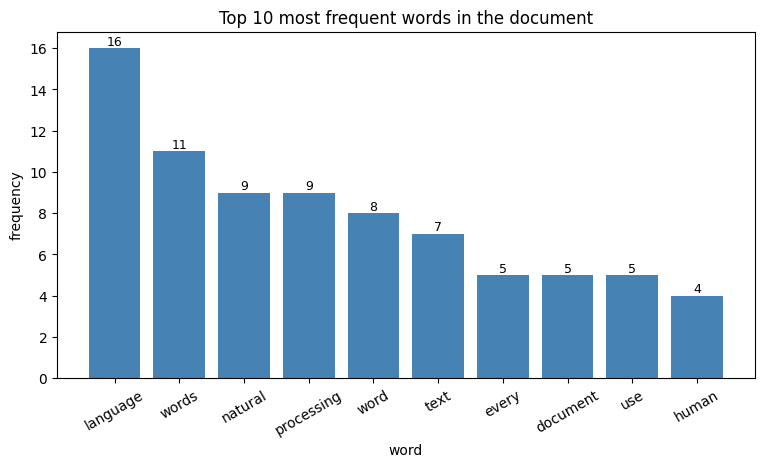

In [11]:
words = [w for w, n in top10]
counts = [n for w, n in top10]

plt.figure(figsize=(9,4.5))
plt.bar(words, counts, color='steelblue')
plt.xlabel("word")
plt.ylabel("frequency")
plt.title("Top 10 most frequent words in the document")
plt.xticks(rotation=30)
for i in range(len(words)):
    plt.text(i, counts[i] + 0.15, str(counts[i]), ha='center', fontsize=9)
plt.show()

The same thing drawn side by side with the list before the stop word removal, the difference is very clear in the picture.

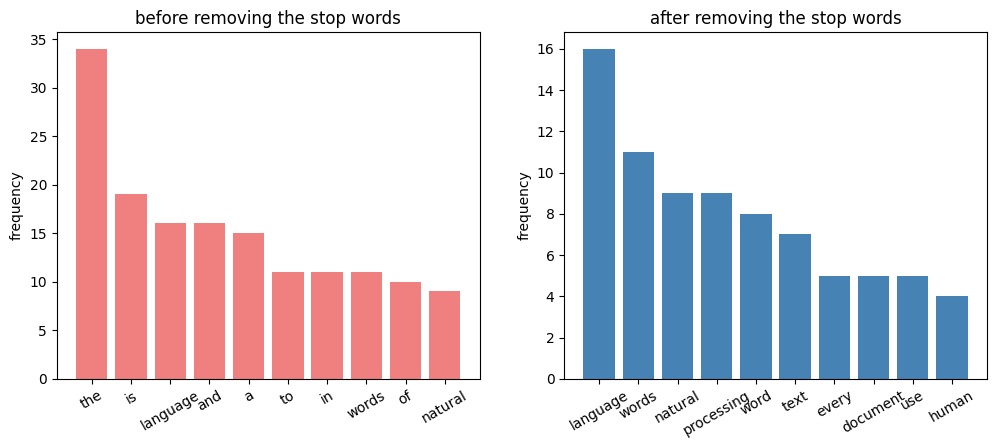

In [12]:
plt.figure(figsize=(12,4.5))

plt.subplot(1,2,1)
bw = [w for w, n in before_top10]
bc = [n for w, n in before_top10]
plt.bar(bw, bc, color='lightcoral')
plt.title("before removing the stop words")
plt.ylabel("frequency")
plt.xticks(rotation=30)

plt.subplot(1,2,2)
plt.bar(words, counts, color='steelblue')
plt.title("after removing the stop words")
plt.ylabel("frequency")
plt.xticks(rotation=30)

plt.show()

One more way of looking at the same result, a horizontal bar graph is easier to read when the words are long.

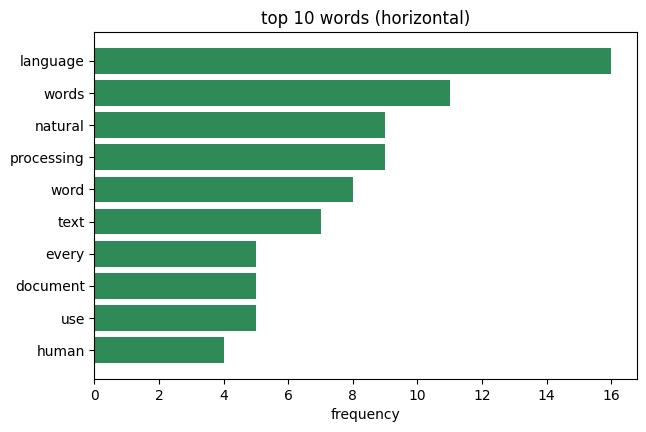

these 10 words together make 79 out of 292 words, that is 27.1 percent of the document


In [13]:
plt.figure(figsize=(7,4.5))
plt.barh(words[::-1], counts[::-1], color='seagreen')
plt.xlabel("frequency")
plt.title("top 10 words (horizontal)")
plt.show()

print("these 10 words together make", sum(counts), "out of", total_after, "words,",
      "that is", round(sum(counts)/total_after*100, 1), "percent of the document")

### Result
A text document was read and preprocessed by converting it to lower case, removing the punctuation marks, tokenizing it into words and removing the stop words, and the word frequencies were then calculated.

| | value |
|---|---|
| Characters in the document | 3071 |
| Total words (tokens) | 500 |
| Words after removing the stop words | 292 |
| Unique words after preprocessing | 178 |
| Stop words and numbers removed | 208 |

**Top 10 most frequent words**

| Rank | Word | Frequency |
|---|---|---|
| 1 | language | 16 |
| 2 | words | 11 |
| 3 | natural | 9 |
| 4 | processing | 9 |
| 5 | word | 8 |
| 6 | text | 7 |
| 7 | every | 5 |
| 8 | document | 5 |
| 9 | use | 5 |
| 10 | human | 4 |

The bar graph of these ten words is plotted above.

### Conclusion
The preprocessing steps were applied on a text document and the word frequency was calculated successfully.

The experiment shows how much the stop word removal changes the result. Before removing them the ten most frequent words were the, is, language, and, a, to, in, words, of, natural, in which seven out of ten are stop words and they say nothing about the document. After removing them the list became language, words, natural, processing, word, text, document, which describes the topic of the article correctly. So a simple frequency count becomes a keyword extractor only after the stop words are taken out.

The counting also shows that the frequency of the words falls very quickly. The first word occurs 16 times while the tenth one occurs only 4 times, and these ten words together cover 79 out of 292 words which is about 27 percent of the whole document. A small number of words is used again and again and a very large number of words is used only once, which is the normal behaviour of any natural language text.

One more point noticed during the experiment is that the plural and the singular form of a word are counted as two different words, `words` with 11 and `word` with 8 are counted seperately although both of them mean the same thing. If lemmatization is also applied before the counting then both of them would join into a single entry of 19 and the result would be even more accurate.

It is concluded that preprocessing is not an optional step, the same document gives a completely different frequency list depending on whether these steps are applied or not.